In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Starting point

In [48]:
df = pd.DataFrame({'col1': [ 1, np.nan, 3, 4, 5, 5],

                    'col2':[np.nan, 20, 30, np.nan, 40, 40],

                    'gender' : ['male', 'female', 'male', 'kid', 'kid', 'kid']
                   
})


df

,col1,col2,gender
0,1.0,NaN,male
1,NaN,20.0,female
2,3.0,30.0,male
3,4.0,NaN,kid
4,5.0,40.0,kid
5,5.0,40.0,kid


### Display duplicated rows and display number of duplicates

In [49]:
df[df.duplicated()]

,col1,col2,gender
5,5.0,40.0,kid


In [50]:
df.duplicated().sum()

np.int64(1)

### Dropni duplikaty

In [51]:
df = df.drop_duplicates().copy()
df

,col1,col2,gender
0,1.0,NaN,male
1,NaN,20.0,female
2,3.0,30.0,male
3,4.0,NaN,kid
4,5.0,40.0,kid


### Add new col 'date' into existing df with date range 

In [52]:
df['date'] = pd.date_range('2025-01-01', periods=5, freq='D')
df

,col1,col2,gender,date
0,1.0,NaN,male,2025-01-01
1,NaN,20.0,female,2025-01-02
2,3.0,30.0,male,2025-01-03
3,4.0,NaN,kid,2025-01-04
4,5.0,40.0,kid,2025-01-05


### Add new col 'col3' using numpy range - use function where you define number of points

In [53]:
df['col3'] = np.linspace(10,100, 5)
df

,col1,col2,gender,date,col3
0,1.0,NaN,male,2025-01-01,10.0
1,NaN,20.0,female,2025-01-02,32.5
2,3.0,30.0,male,2025-01-03,55.0
3,4.0,NaN,kid,2025-01-04,77.5
4,5.0,40.0,kid,2025-01-05,100.0


### Show all NaN

In [54]:
df[df.isna().any(axis=True)]

,col1,col2,gender,date,col3
0,1.0,NaN,male,2025-01-01,10.0
1,NaN,20.0,female,2025-01-02,32.5
3,4.0,NaN,kid,2025-01-04,77.5


### Create new df with all NaNs dropped

In [55]:
df2 = df.dropna().copy()
df2

,col1,col2,gender,date,col3
2,3.0,30.0,male,2025-01-03,55.0
4,5.0,40.0,kid,2025-01-05,100.0


### Create new df with all NaNs filled in with a word

In [56]:
df3 = df.fillna('replaced')
df3

,col1,col2,gender,date,col3
0,1.0,replaced,male,2025-01-01,10.0
1,replaced,20.0,female,2025-01-02,32.5
2,3.0,30.0,male,2025-01-03,55.0
3,4.0,replaced,kid,2025-01-04,77.5
4,5.0,40.0,kid,2025-01-05,100.0


### Create new_col and fill  NaN in col2  with a value 1000 using where

In [57]:
df['new_col'] = np.where(df['col2'].isna(), 0.1, df['col2'])
df

,col1,col2,gender,date,col3,new_col
0,1.0,NaN,male,2025-01-01,10.0,0.1
1,NaN,20.0,female,2025-01-02,32.5,20.0
2,3.0,30.0,male,2025-01-03,55.0,30.0
3,4.0,NaN,kid,2025-01-04,77.5,0.1
4,5.0,40.0,kid,2025-01-05,100.0,40.0


### Fill all NaN in numeric cols with MEAN

In [58]:
df = df.fillna(df.mean(numeric_only=True))
df

,col1,col2,gender,date,col3,new_col
0,1.00,30.0,male,2025-01-01,10.0,0.1
1,3.25,20.0,female,2025-01-02,32.5,20.0
2,3.00,30.0,male,2025-01-03,55.0,30.0
3,4.00,30.0,kid,2025-01-04,77.5,0.1
4,5.00,40.0,kid,2025-01-05,100.0,40.0


### Plot line chart with markers and grid and size - define x and y axis, and define names of x and y axis

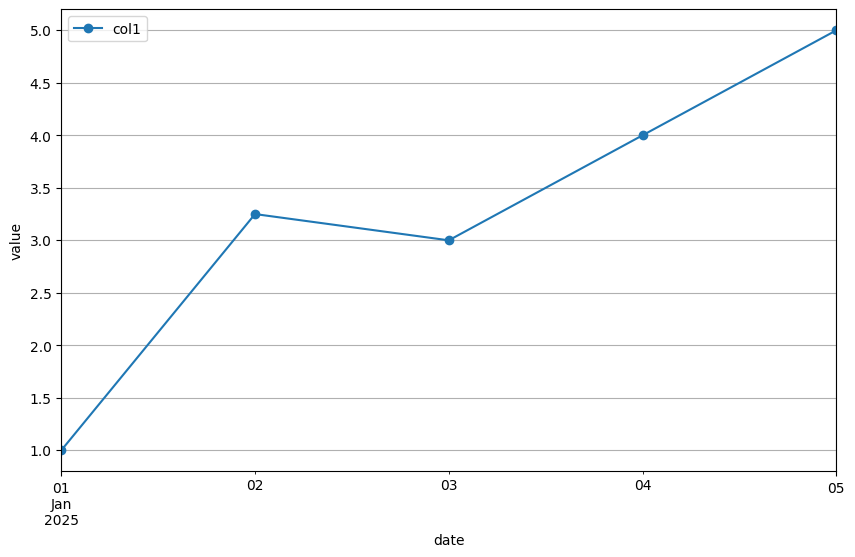

In [59]:
df.plot(x='date',
        y='col1',
        figsize=(10,6),
        marker='o'
        )

plt.xlabel('date')
plt.ylabel('value')
plt.grid(True)
plt.show()

### Udelej scatter plot v plotly express a proloz to body primkou

In [60]:
import plotly_express as px


fig = px.scatter(df, x='col1', y='col2', width=800, height=600, trendline='ols'
                                 
                 )
fig.show()


### Print in both rows with one line of code

In [61]:
var1 = 10
var2 = 20

In [62]:
print(f' var1 {var1} \n var2 {var2}')

 var1 10 
 var2 20


### Import metric for rmse and get value from col1 and col2

In [63]:
from sklearn.metrics import root_mean_squared_error

error = round(root_mean_squared_error(df['col1'], df['col2']),2)
error

27.39

### Plot boxplot, and histogram 

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({'values':[50, 100, 750, 768, 860, 899, 950, 4000, 3000]})
df

,values
0,50
1,100
2,750
3,768
4,860
5,899
6,950
7,4000
8,3000


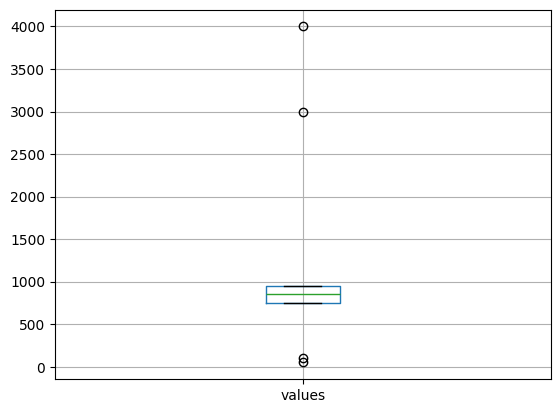

In [65]:
df.boxplot()
plt.show()

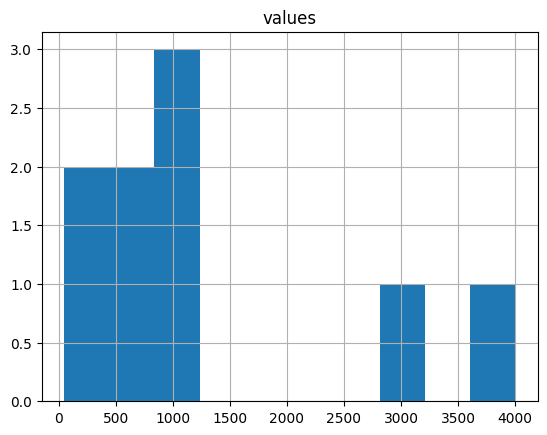

In [66]:
df.hist(bins=10)
plt.show()

### Remove outliers and plot the box plot again

In [67]:
q1 = df['values'].quantile(0.25)
q3 = df['values'].quantile(0.75)


iqr = q3-q1

lower_whisker = q1-1.5*iqr
upper_whisker = q3+1.5*iqr


df['values'] = df[(df['values']>=lower_whisker) & (df['values']<=upper_whisker)]


<Axes: >

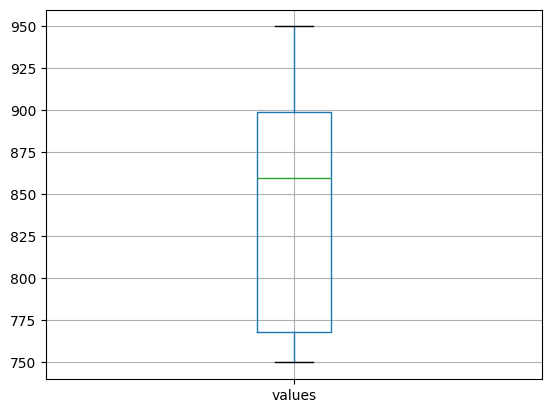

In [68]:
df.boxplot()

### Split dates - slicing

In [ ]:
data = pd.DataFrame({'date': pd.date_range('2025-01-01', periods=10, freq='D'),
                           'value': np.linspace(10,100,10)
 
                           })

data

,date,value
0,2025-01-01,10.0
1,2025-01-02,20.0
2,2025-01-03,30.0
3,2025-01-04,40.0
4,2025-01-05,50.0
5,2025-01-06,60.0
6,2025-01-07,70.0
7,2025-01-08,80.0
8,2025-01-09,90.0
9,2025-01-10,100.0


In [70]:
train = data[:7].copy(0)
train

,date,value
0,2025-01-01,10.0
1,2025-01-02,20.0
2,2025-01-03,30.0
3,2025-01-04,40.0
4,2025-01-05,50.0
5,2025-01-06,60.0
6,2025-01-07,70.0


In [71]:
test = data[-3:].copy()
test

,date,value
7,2025-01-08,80.0
8,2025-01-09,90.0
9,2025-01-10,100.0


### Group by name and gender and sum profit and order col name

In [72]:
import pandas as pd
import numpy as np

df=pd.DataFrame({   'name': ['John','Lucy','Alice','John','Mike', 'Mike', 'Alex','Lucy', 'John'],
                    'profit_usd': [50, 60, 100, 65, 700, 55, 150, 45, 75],
                    'gender': ['man', 'woman', 'woman', 'man','man','man','man', 'woman', 'man'],
                  })

df

,name,profit_usd,gender
0,John,50,man
1,Lucy,60,woman
2,Alice,100,woman
3,John,65,man
4,Mike,700,man
5,Mike,55,man
6,Alex,150,man
7,Lucy,45,woman
8,John,75,man


In [73]:
df_grouped = (df.groupby(['name', 'gender'])
                .agg({'profit_usd':'sum'})
                .reset_index()
                .sort_values('name', ascending=False)
              
)

df_grouped

,name,gender,profit_usd
4,Mike,man,755
3,Lucy,woman,105
2,John,man,190
1,Alice,woman,100
0,Alex,man,150


### Merge 2 dataframes via customer and fill NaN with zeros

In [74]:
import pandas as pd

df1 = pd.DataFrame({
                    'customer':['John', 'Alice', 'Tom', 'Peter'],
                    'profit-June': [100, 200, 300, 400]
                    })

df1

,customer,profit-June
0,John,100
1,Alice,200
2,Tom,300
3,Peter,400


In [75]:
df2 = pd.DataFrame({
                    'customer':['John', 'Karin', 'Martin', 'Tom'],
                    'profit-July': [100, 200, 300, 400]
                    })


df2

,customer,profit-July
0,John,100
1,Karin,200
2,Martin,300
3,Tom,400


In [76]:
df_merged = pd.merge(df1, df2, on=['customer'], how='left').fillna(0)
df_merged

,customer,profit-June,profit-July
0,John,100,100.0
1,Alice,200,0.0
2,Tom,300,400.0
3,Peter,400,0.0


### Concat 2 dfs

In [77]:
import pandas as pd

df1 = pd.DataFrame({
                    'customer':['John', 'Alice', 'Tom', 'Peter'],
                    'profit': [100, 200, 300, 400]
                    })

df1

,customer,profit
0,John,100
1,Alice,200
2,Tom,300
3,Peter,400


In [78]:
df2 = pd.DataFrame({
                    'customer':['John', 'Karin', 'Martin', 'Tom'],
                    'profit': [100, 200, 300, 400]
                    })

df2

,customer,profit
0,John,100
1,Karin,200
2,Martin,300
3,Tom,400


In [80]:
conc_df = pd.concat([df1, df2], axis=0)
conc_df

,customer,profit
0,John,100
1,Alice,200
2,Tom,300
3,Peter,400
0,John,100
1,Karin,200
2,Martin,300
3,Tom,400
